In [1]:
%pip install classy camb arviz numpy matplotlib cobaya

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# tools
import arviz as az # Library for Bayesian analysis

# Bayesian inference
import cobaya
# Theory codes
import classy
import camb


# Tips for MCMC

In [3]:
# 3-parameter cosmolgoy fit [H0, omega_b, omega_c]
# Chains obtained using emcee (not Metropolis-Hastings)
# Shape of the array is [n_chains, n_samples, n_params]
# n_chains=4, n_samples=16384, n_params=3
LCDM_chains = np.load("chains/LCDM_chains.npy")
if az.__version__[0] == "1":
    idata = az.from_dict(data={"posterior": {param: LCDM_chains[:,:,i] for i, param in enumerate(["H0", "omega_b", "omega_c"])}})
else:
    idata = az.from_dict(posterior={param: LCDM_chains[:,:,i] for i, param in enumerate(["H0", "omega_b", "omega_c"])})

## Multimodality

In [4]:
def f_gaussian(x, mean, std):
    return np.exp(-0.5*(x-mean)**2/std**2)/np.sqrt(2*std**2*np.pi)

def multimodality_example(start=0, n_steps=100, separation=3, amplitude1=0.5, amplitude2=0.5):
    f_distribution = lambda x: amplitude1*f_gaussian(x, -abs(separation), 0.5) + amplitude2*f_gaussian(x, abs(separation), 0.5)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.linspace(-6, 6, 10_000)
    y = f_distribution(x)
    
    step_count = 0
    steps = [[start], [f_distribution(start)]]
    while step_count < n_steps:
        new_step = np.random.normal(steps[0][-1], 0.5)
        new_step_value = f_distribution(new_step)
        if (new_step_value > steps[1][-1]):
            steps[0].append(new_step)
            steps[1].append(new_step_value)
            step_count+=1
        else:
            p = np.random.random(1)
            if (new_step_value/steps[1][-1] > p):
                steps[0].append(new_step)
                steps[1].append(new_step_value)
                step_count+=1


    ax.plot(x, y)
    ax.plot(steps[0], steps[1], color="red", marker="o", markersize=5, markerfacecolor="green")
    ax.set_yscale("log")
    ax.set_xlabel("x")
    ax.set_ylabel("logL")

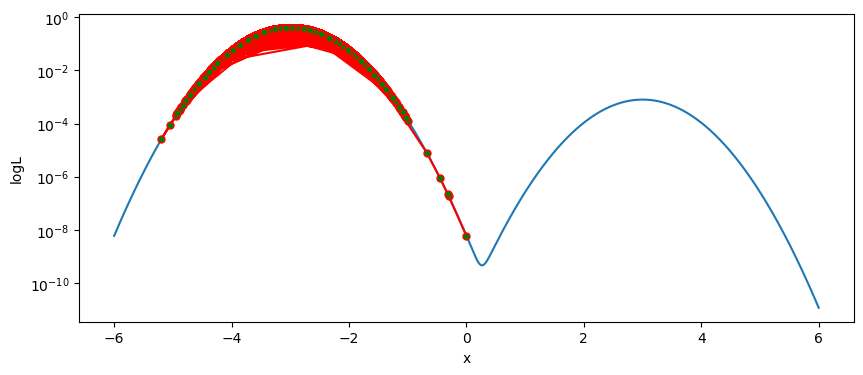

In [5]:
multimodality_example(start=0, n_steps=100_000, amplitude2=1e-3, separation=3)

Many MCMC algortihms struggle with multimodality, especially Metropolis-Hastings. The problem arises becauses the next step depends on the previous one and it is difficult to cross the "valley" (low probability region) between the peaks. Of course it the peaks are close engouh then we can still sample correctly. So the main problem with multimodality is that the walker(s) can get stuck in one modality and doesn't sample the true posterior correctly. This means that the analysis later on are incorrect.

 The easiest way to detect multimodality is visual. It is good practice to run multiple walkers (chains) per one analysis which are initialized far away from each other. Multiple walkers are useful to determine if the chains are converged (sampling the true posterior). So having them starting in different locations it is more probable that at least one walker finds another peak and then gets stuck there. Later in the run it is possible to plot the walker's path and see if it is stuck. If it is stuck it is good to see, what is the posterior value at the mode, as it can turn out it is not relevant at all $\Delta \text{logL} \gtrsim 15-20 $.

There are options to solve multimodality, although it is not guaranteed. Usually this means using different transition rules/algorithms.

### Parallel tempering

The main idea of **parallel tempering** algorithm is to run multiple chains with different **"temperatures"**. The higher the temperature the more exploratory the chain is. Then the $T=1$ (lowest temperature) chain can swap between higher temperature chain and thus is able to change modes. The true samples are generated only by the lowest temperature chains and higher temperature chains are just helping. The output is thus only one chain.

### Nested sampling

Nested sampling is now different algorithm, which main objective is to calculate the evidence. But it can also be used for posterior sampling as it samples also in low likelihood regions. Frequently used program for nested sampling is [**Polychord**](https://arxiv.org/abs/1506.00171).

## Burn-in, chain convergence and autocorrelation

The output of the Metropolis-Hastings algorithm are the chains. At the beginning the chain values are dependent on the initial position of the chain and step by step it gets closer to the high probability region. So the initial values have not usually sampled properly the true posterior. To get rid of the bias due to the initial position it is good practice to use **burn-in**, which means discarding the first $N$ steps. Using burn-in helps to discard biased steps and get our estimate for the posterior more accurate.  There is no fixed value how many steps should be discarded, but the general approach is $10-30%$ of the total steps. The main decision should be made on different diagnostic measures.




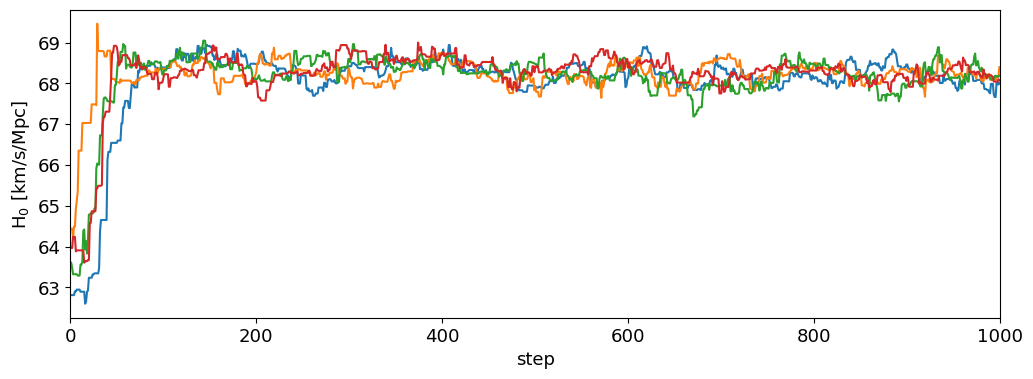

In [6]:
with plt.rc_context({"font.size": 13}):
    LENGTH = 1000
    plt.figure(figsize=(12, 4))
    for i in range(LCDM_chains.shape[0]):
        plt.plot(LCDM_chains[i, :LENGTH, 0])
    plt.xlabel("step")
    plt.xlim(0, LENGTH)
    plt.ylabel(r"$\text{H}_0$ [km/s/Mpc]")

When the chains are sampling stationary distribution (hopefully estimation for the posterior) we say the chain has **converged**. This essentially means that the initial position does not have any effect on the sampling process. Easiest way to see convergence is to look at the chains' trace plot and see how the samples are sampling. Another, more quantitative way is to use Gelman-Rubin Statistic ($\hat{R}$). This measure is also usefule for detecting multimodality. The definition for $\hat{R}$ is 
\begin{equation}
    \begin{split}
        &\overline{\theta_j} = \frac{1}{N} \sum_{i=1}^{N} \theta_i^{(j)} \text{(mean of the chain)}\,, \quad \overline{\theta}_{*} = \frac{1}{M}\sum_{j=1}^{J}\overline{\theta}_j\ \text{(mean of the means of all chains)}\\
        & B = \frac{L}{J-1}\sum_{j=1}^{L} (\overline{\theta}_j - \overline{\theta}_*)^2\quad \text{(variance of the means of the chains)}\\
        & W = \frac{1}{J}\sum_{j=1}^{J}\left(\frac{1}{L-1}\sum_{i=1}^{L}(\theta_i^{j} - \overline{\theta}_j)^2 \right)\quad \text{(averaged variances of the individual chains)}
    \end{split}
\end{equation}

where $N$ is samples inside a chain and $J$ is the number of chains.

and 
\begin{equation}
    \hat{R} =  \frac{\frac{N-1}{N}W + \frac{1}{N}B}{W} \,.
\end{equation}

Unpacking the meaning of all these variables:
* $W$ estimates the variance within the chain
* $B$ estimates the variance between the chains
* $\frac{N-1}{N}W + \frac{1}{N}B$ is a weighted estimate of the total variance

When $N\Rightarrow 1$ then $B\Rightarrow 0$ and $R\Rightarrow 1$. So the limit, where chain has converged represents where $\hat{R} \approx 1$. It is common to take $\hat{R}-1 \leq 1.01$ as the condition for saying the chains have converged. 

In [7]:
# Let's use arviz to calculate Rhat
# Change range of data to see how Rhat changes
az.rhat(idata) 

<xarray.Dataset> Size: 24B
Dimensions:  ()
Data variables:
    H0       float64 8B 1.002
    omega_b  float64 8B 1.002
    omega_c  float64 8B 1.002

Less common statistic is **Effective sample size (ESS)**, but in some situations it is useful. To calculate ESS we need to calculate **autocorrelation** which shows how dependent the samples to each other are. Autocorrelation is defined as 

\begin{equation}
    \rho_\tau = \frac{c_\theta(\tau)}{c_\theta(0)}\,, \text{where } c_\theta = \frac{1}{N-\tau}\sum_{n=1}^{N-\tau}(\theta_n-\overline{\theta})(\theta_{n+\tau}-\overline{\theta}) 
\end{equation}

In [8]:
# Autocorrelation plot
if az.__version__[0]=="1":
    az.style.use("arviz-variat")
    az.plot_autocorr(idata, var_names=["H0"])
    az.plot_autocorr(idata, var_names=["omega_b"])
    az.plot_autocorr(idata, var_names=["omega_c"])


Now coming back to ESS. Without going too specific in the definition, the ESS simply estimates how many independent samples we have. As the samples usually are correlated to each other (quantified by the autocorrelation) then the "real" sample size is always smaller. The definition for ESS is following
\begin{equation}
    \text{ESS} = \frac{N}{1 + 2 \sum_{k=1}^{\infty}\rho_k}\,.
\end{equation}
The Effective sample saize gives precision for the posterior estimate
\begin{equation}
    \text{Var}(\hat{\theta}) \approx \frac{\sigma^2}{\text{ESS}}
\end{equation}

where $\hat{\theta}$ is some estimate of a parameter (for example mean for $\theta$) and $\sigma$ is posterior variance.

In [9]:
# Effective sample size
az.ess(idata)

<xarray.Dataset> Size: 24B
Dimensions:  ()
Data variables:
    H0       float64 8B 1.77e+03
    omega_b  float64 8B 1.65e+03
    omega_c  float64 8B 1.711e+03

## Model comparison

### Bayes factor

One way to compare models is to use Bayes factor which we mentioned in the first lecture. This is the ratio between two models' evidences.

\begin{equation}
    \text{BF}_{12} = \frac{P(D|M_1)}{P(D|M_2)} 
\end{equation}

We want around $\text{BF}_{12} \gtrsim 3$ to say some preference to one model.

### Maximum likelihood methods

#### Akaike Information Criterion (AIC)

AIC is estimator of prediction error. It has two componesnts: how good the fit is and how overfitted the model is. Lower value for AIC means better model. By definition

\begin{equation}
    \text{AIC} = 2k - 2 \log(\hat{L})
\end{equation}
where $\hat{L}$ is maximum value of the likelihood and k is the count of free parameters. Here we can the the more free parameters, the higher the AIC value is . Also, the lower the log-likelihood, the better the fit and lower AIC. 

To have some more quantitative estimation between models, let's say we have multiple models with different AIC values. $AIC_*$ is the lowest of them. Then calculating the value
\begin{equation}
    \exp\left(\frac{AIC_* - AIC_n}{2}\right)
\end{equation}

gives estimate how probably the $n$-th model minimizes the information loss compared to the $AIC_*$ model.

It is important, that AIC value itself does not give any information. It is only informative when comparing to another models using the same dataset.

### Bayesian Information Criterion (BIC)

It is related to AIC value. Again, this value is penalized by having more free parameters but gets smaller value, when log-likelihood is smaller. 

BIC tries to estimate the evidence, thus making it possible to get the esimates for Bayes factor. BIC is defined as 
\begin{equation}
    \text{BIC} = k \log(n) - 2 \log(\hat{L})
\end{equation}

where $n$ now is number of data points used to fit the model. BIC is greater then AIC if $n>7$. Like AIC the smaller the value for BIC the better the model is. Also, BIC value itself does not say how good the model is. We need to compare different BIC values to each other, so $\Delta\text{BIC} =  \text{BIC}_2 - \text{BIC}_1 \approx -2 \log(\text{BF}_{12})$.



# Tools

## Cobaya

[Cobaya](https://cobaya.readthedocs.io/en/latest/) is a tool, created by Jesus Torrado and Anthony Lewis, used in cosmology which helps to combine multiple datastes to perform Bayesian inference. It's main architecture is based on Python programming language. It has fast access to multiple likelihoods (with data):
 * different CMB likelihoods (Planck, BICEP/KECK)
 * multiple type Ia Supernovae likelihoods
 * BAO measurements (DESI)

It includes interfaces to theory codes CAMB and CLASS, which are neccessary to calculate CMB multipole spectras. It also includes access to couple of samplers:
 * Modified Metropolist-Hastings
 * Polychord (nested sampler)

 Especially useful are the access to CMB likelihoods and intefraces to CLASS/CAMB which might need more proficiency in coding.

 For analysis the user must define config (yaml format) file, which includes different settings for analysis:
    * Likelihood settings (what likelihoods are used and settings for these)
    * Prior settings (what type of priors to use for each parameters)
    * Parameter settings (list of parameters which are fixed, sampled or derived from the analysis + some metadata about these)
    * Sampler settings
    * Theory settings (settings used in theory codes like CLASS or CAMB)

If the config file is defined then running the analysis is simple.

In general it is possible to define new likelihoods, add new sampler or customize most of the analysis progress.

## CLASS

[CLASS](http://class-code.net/) is code in C (and some in C++) to simulate the evolution of linear perturbations in the universe and computing CMB and large scale structure observables. CLASS has Python wrapper "classy" making running CLASS easier. If running $\Lambda$CDM or similar, then probably CLASS has it implemented and can be used through classy right away. In some cases it is neccessary to modify CLASS source code and install classy through that to use the modified CLASS'. 

### Horndeski
If you are interested in Horndeski's theories then CLASS has modification called [``hi_class``](https://miguelzuma.github.io/hi_class_public/). Horndeski is general scalar-tensor theory described by second-order equations of motion. This code allows to define your wanted Horndeski theory Lagrangian and then calculate CMB observables. There is also a modification to hi_class called [``mochi_class``](https://github.com/mcataneo/mochi_class_public) which is update version and allows some more functionality/stability. 


## CAMB

[CAMB](https://camb.info/) is similar code to CLASS, but is a bit older and written in Fortran.

### EFTCAMB

[EFTCAMB](http://eftcamb.org/) is a modified version of CAMB which uses effective field theory approach to single scalar field and modified gravity models. Compared to CLASS it can also calculate $f(R)$ theories

<figure  style="text-align: center;">
  <img src="images/TheoryCodes.png" alt="Comaprison between theory codes" style="width: 90%; height: auto;">
  <figcaption>Capabilities of different theory codes. Figure from Bellini, E., Barriera, A., Frusciante, N. et al, "A comparison of Einstein-Boltzmann solvers for testing General Relativity" <a>https://arxiv.org/pdf/1709.09135</a></figcaption>
</figure> 

## Comparison

In [10]:
settings = {
    # Values from Planck 2018 best-fit for base LCDM_CLASS
    "h": 0.6732,
    "omega_b": 0.022383,
    "omega_cdm": 0.12011,
    "tau_reio": 0.0543,
    "A_s": 2.1005829616811546e-09,
    "n_s": 0.96605,
    # Output and precision parameters
    # tCl->Temperature power spectra, pCl->Polarization power spectra
    # lCl->Lensing potential power spectra, mPk->Matter power spectra
    'output':'tCl,pCl,lCl,mPk', 
    'lensing':'yes',
    'l_max_scalars':5000,
    'z_max_pk': 100,
    # 'non linear': 'halofit',
    'P_k_max_h/Mpc': 200.0,
}
# Everything is measured in units of Mpc
LCDM_CLASS = classy.Class()
LCDM_CLASS.set(settings)
LCDM_CLASS.compute()

In [11]:
# Example: get matter power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.32, ombh2=0.022383, omch2=0.12011)
pars.InitPower.set_params(ns=0.96605, As=2.1005829616811546e-09)
pars.Reion.set_tau(0.0543)
pars.set_for_lmax(5000)
pars.set_matter_power(redshifts=[0], kmax=100)
LCDM_CAMB = camb.get_results(pars)

### Matter power spectrum

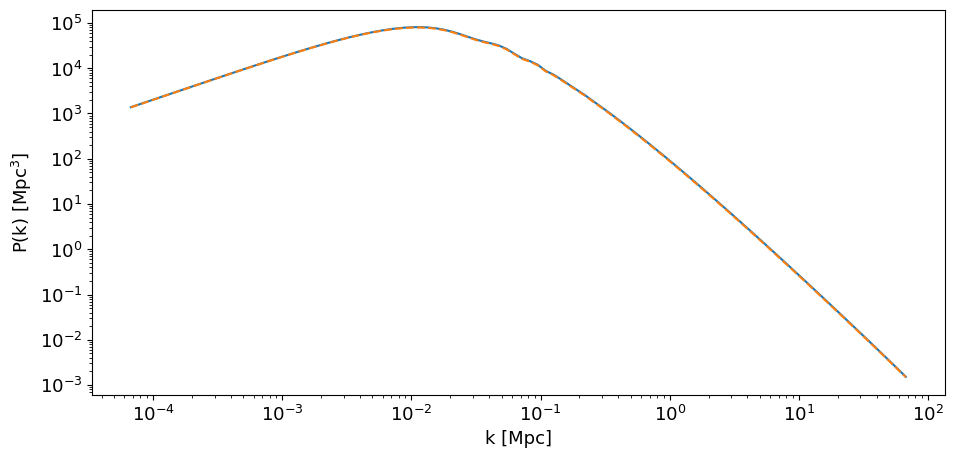

In [13]:
with plt.rc_context({"font.size": 13}):
    fig, ax = plt.subplots(figsize=(11, 5))
    _mPk_CAMB = LCDM_CAMB.get_matter_power_spectrum(1e-4, 100)
    k_values = _mPk_CAMB[0]*0.6732
    # CLASS variables in units of [k] = Mpc and [P(k)] = Mpc^3
    # CAMB variables in units of [k] = Mpc/h and [P(k)] = (Mpc/h)^3
    _mPk_CLASS = np.array([LCDM_CLASS.pk(k=k, z=0) for k in k_values])
    ax.plot(k_values, _mPk_CLASS)
    ax.plot(k_values, _mPk_CAMB[2][-1]/0.6732**3, linestyle="--")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("k [Mpc]")
    plt.ylabel(r"P(k) [$\text{Mpc}^3$]")

### Angular distance

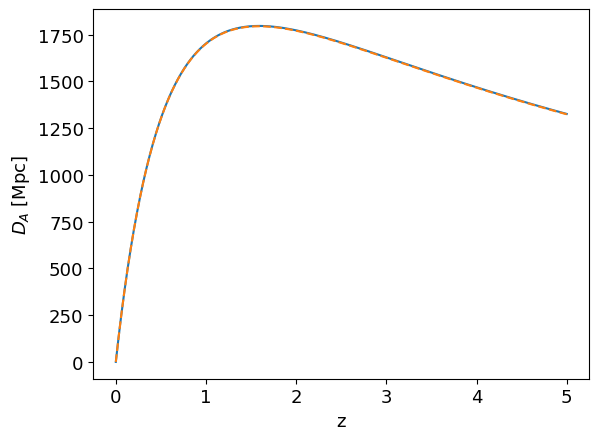

In [14]:
with plt.rc_context({"font.size": 13}):

    z_values = np.linspace(0, 5, 1001)
    plt.plot(z_values, LCDM_CLASS.angular_distance(z_values))
    plt.plot(z_values, LCDM_CAMB.angular_diameter_distance(z_values), linestyle="--")

    plt.xlabel("z")
    plt.ylabel("$D_A$ [Mpc]")

### Angular power spectrum of CMB

In [15]:
def plot_class_cl(ax, data, key):
    l = data["ell"]
    constant=l*(l+1)/(2*np.pi)
    ax.plot(l, data[key]*constant, label="CLASS")

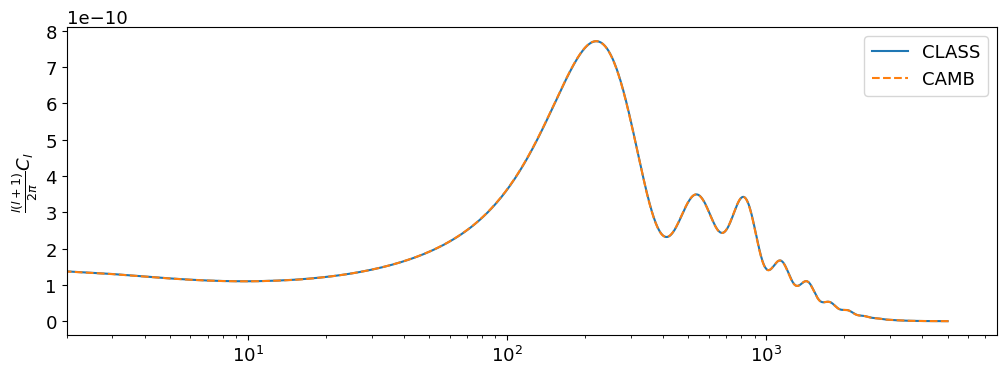

In [16]:
with plt.rc_context({"font.size": 13}):
    fig, ax = plt.subplots(figsize=(12, 4))
    # CAMB: 0=TT, 1=EE, 2=BB, 3=TE
    camb_idx = 0
    plot_class_cl(ax, LCDM_CLASS.lensed_cl(), "tt")
    ax.plot(LCDM_CAMB.get_cmb_power_spectra(pars)["total"][:, camb_idx], linestyle="--", label="CAMB")
    ax.set_xscale("log")
    ax.set_xlim(2)
    ax.legend()
    ax.set_ylabel("$\\frac{l(l+1)}{2\\pi}C_l$")